In [3]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('/content/advertising.csv')

# Basic exploration
print(df.shape)
print(df.head(10))
print(df.describe())
print(df.dtypes)

(200, 4)
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
5    8.7   48.9       75.0    7.2
6   57.5   32.8       23.5   11.8
7  120.2   19.6       11.6   13.2
8    8.6    2.1        1.0    4.8
9  199.8    2.6       21.2   15.6
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


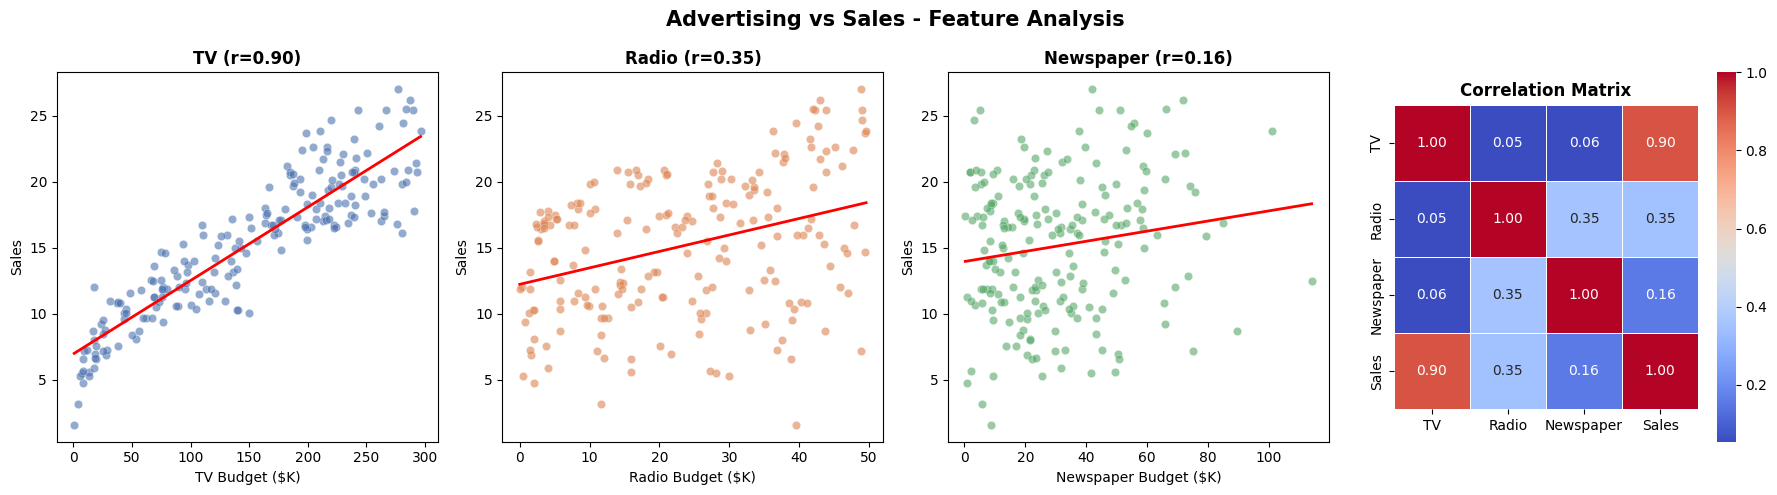

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Advertising vs Sales - Feature Analysis', fontsize=15, fontweight='bold')

colors = {'TV': '#4C72B0', 'Radio': '#DD8452', 'Newspaper': '#55A868'}

for i, col in enumerate(['TV', 'Radio', 'Newspaper']):
    axes[i].scatter(df[col], df['Sales'], alpha=0.6, color=colors[col],
                    edgecolors='white', linewidths=0.3)

    # Trend line
    m, b = np.polyfit(df[col], df['Sales'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red', linewidth=2)

    corr = df[col].corr(df['Sales'])
    axes[i].set_title(f'{col} (r={corr:.2f})', fontweight='bold')
    axes[i].set_xlabel(f'{col} Budget ($K)')
    axes[i].set_ylabel('Sales')

# Correlation heatmap
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[3], square=True, linewidths=0.5)
axes[3].set_title('Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Features and target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [6]:
metrics = {}

for name, y_pred in [('Linear Regression', y_pred_lr), ('Random Forest', y_pred_rf)]:
    metrics[name] = {
        'R2':   r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE':  mean_absolute_error(y_test, y_pred)
    }

for model, vals in metrics.items():
    print(f"{model}:")
    print(f"  R²   = {vals['R2']:.4f}")
    print(f"  RMSE = {vals['RMSE']:.4f}")
    print(f"  MAE  = {vals['MAE']:.4f}")
    print()

# Linear Regression Coefficients
print("Linear Regression Coefficients:")
for feat, coef in zip(['TV', 'Radio', 'Newspaper'], lr.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"  Intercept: {lr.intercept_:.4f}")

Linear Regression:
  R²   = 0.9059
  RMSE = 1.7052
  MAE  = 1.2748

Random Forest:
  R²   = 0.9535
  RMSE = 1.1989
  MAE  = 0.9180

Linear Regression Coefficients:
  TV: 0.0545
  Radio: 0.1009
  Newspaper: 0.0043
  Intercept: 4.7141


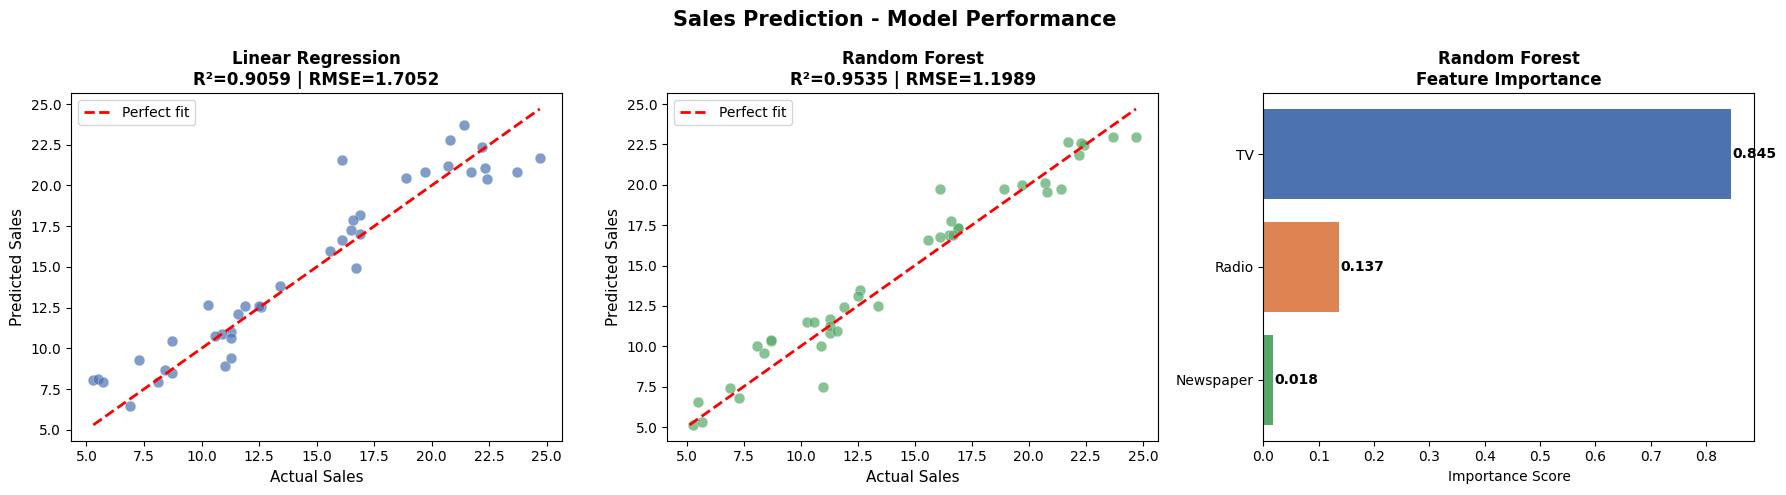

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sales Prediction - Model Performance', fontsize=15, fontweight='bold')

# Actual vs Predicted for both models
for ax, (name, y_pred, color) in zip(axes[:2], [
    ('Linear Regression', y_pred_lr, '#4C72B0'),
    ('Random Forest',     y_pred_rf, '#55A868')
]):
    ax.scatter(y_test, y_pred, alpha=0.7, color=color,
               edgecolors='white', linewidths=0.3, s=60)

    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect fit')

    r2   = metrics[name]['R2']
    rmse = metrics[name]['RMSE']
    ax.set_title(f'{name}\nR²={r2:.4f} | RMSE={rmse:.4f}', fontweight='bold')
    ax.set_xlabel('Actual Sales', fontsize=11)
    ax.set_ylabel('Predicted Sales', fontsize=11)
    ax.legend()

# Random Forest Feature Importance
importance = pd.Series(rf.feature_importances_,
                        index=['TV', 'Radio', 'Newspaper']).sort_values()

bars = axes[2].barh(importance.index, importance.values,
                    color=['#55A868', '#DD8452', '#4C72B0'])
axes[2].set_title('Random Forest\nFeature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')

for bar, val in zip(bars, importance.values):
    axes[2].text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Predict sales for a new advertising budget
new_data = pd.DataFrame({
    'TV':        [150.0],
    'Radio':     [25.0],
    'Newspaper': [30.0]
})

print("Linear Regression prediction:", lr.predict(new_data)[0].round(2))
print("Random Forest prediction:    ", rf.predict(new_data)[0].round(2))

Linear Regression prediction: 15.54
Random Forest prediction:     14.59
